# Capstone Black Box Project

## Function 2 - Log Likelihood Score

2D noisy log-likelihood surface — feeding two numbers (x1, x2) into an unknown model and getting back a log-likelihood score, plus noise on every read. Log-likelihood is a single number that measures how well a set of parameters explains observed data — specifically, the logarithm of the probability of seeing the data you actually saw, if those parameter values were the true ones

### Submission 10 of 13

In [14]:
#Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress

## 1. Load Data

In [23]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_2" # Define the function being analysed

def load_npy_files(function_name):
    initial_inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    initial_outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return initial_inputs, initial_outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 19
[[0.718593 0.874372]
 [0.708809 0.892037]]
[0.60190471 0.50979202]


## 2. Describe and Review Data

In [4]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())

               0          1
count  19.000000  19.000000
mean    0.618474   0.482984
std     0.190465   0.377622
min     0.142699   0.000000
25%     0.516180   0.087110
50%     0.686869   0.546276
75%     0.713701   0.826500
max     0.877791   0.979798
               0
count  19.000000
mean    0.354164
std     0.235498
min    -0.065624
25%     0.187058
50%     0.420586
75%     0.551684
max     0.633054


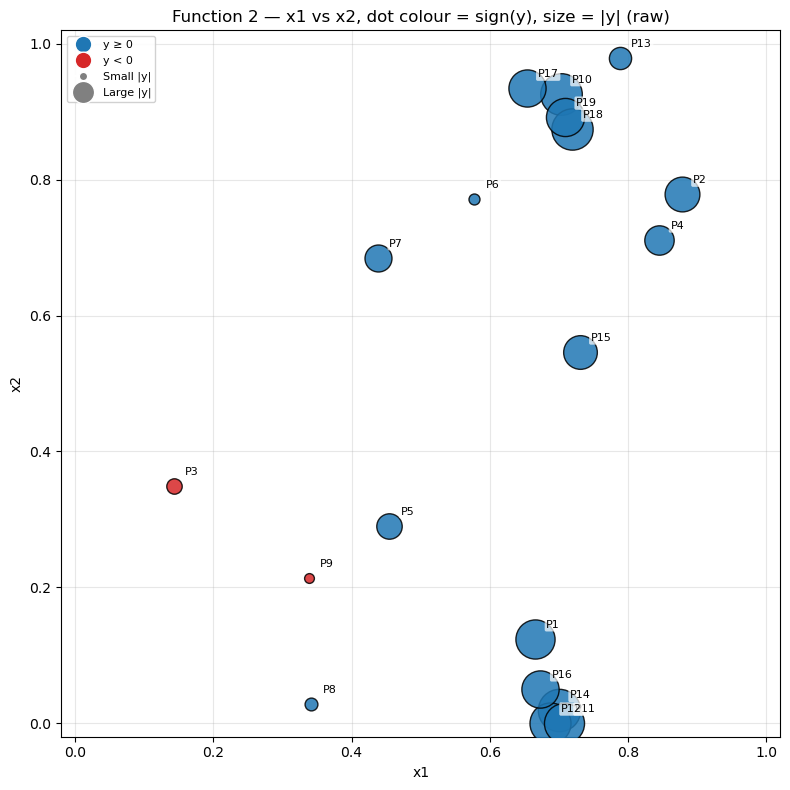

In [8]:
# Plot raw Y values versus X1 (x axis) and X2 (y axis) with magnitude represented by size and sign by colour

labels = [f"P{i+1}" for i in range(len(y))]
colors = np.where(y >= 0, 'tab:blue', 'tab:red')            # sign
sizes = 30 + 900 * (np.abs(y) / np.abs(y).max())            # magnitude

# Draw largest markers first, smallest last, so small markers aren't
# hidden underneath nearby large ones (e.g. P5 next to P13, 0.0146 apart)
order = np.argsort(-sizes)

fig, ax = plt.subplots(figsize=(8, 8))
for i in order:
    ax.scatter(X[i, 0], X[i, 1], c=colors[i], s=sizes[i], alpha=0.85,
               edgecolors='k', linewidths=1.0, zorder=3)

for i, (x1, x2) in enumerate(X):
    if np.abs(y[i]) > 1e-4:  # only label points with meaningful signal
        ax.annotate(labels[i], (x1, x2), textcoords="offset points", xytext=(8, 8), fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=12, label='y ≥ 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=12, label='y < 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=6, label='Small |y|'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=16, label='Large |y|'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=8, framealpha=0.9)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_title('Function 2 — x1 vs x2, dot colour = sign(y), size = |y| (raw)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Transform Data

In [11]:
# No transforms applied

y_fit = y

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./Data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_2 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

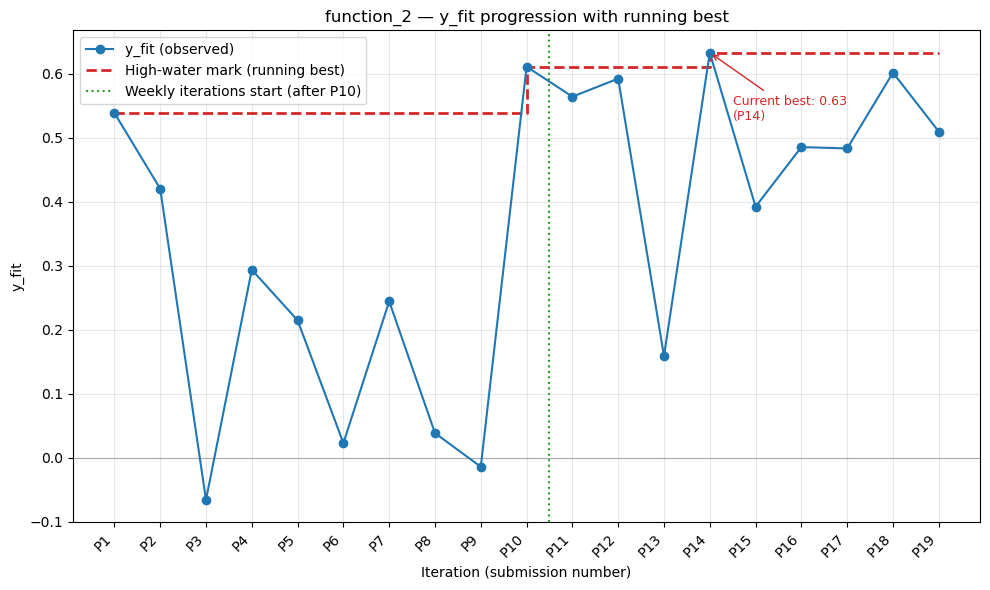

In [12]:
# Point labels and y_fit values to monitor progress
plot_progress(y_fit, labels=None, iteration_start=10, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernel

In [15]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5)
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5)
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5)
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    # single scalar — isotropic
    #'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.05, 2.0)), #wk 3, wk 5
    #'RBF4':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), #wk 4
    #'RBF6':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), #wk 6
    # --- Week 7: noisy variants: same structure + fitted observation noise ---
    'RBF7':   ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    pinned = "  [PINNED: " + "; ".join(str(warn.message).split(".")[0] for warn in w) + "]" if w else ""
    print(f"{name:18s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}{pinned}")

Matern_2.5          LML=-21.7218  AIC=49.4435  BIC=52.2768  kernel=0.994**2 * Matern(length_scale=0.122, nu=2.5) + WhiteKernel(noise_level=0.0789)
Matern_1.5          LML=-21.6947  AIC=49.3894  BIC=52.2227  kernel=0.999**2 * Matern(length_scale=0.136, nu=1.5) + WhiteKernel(noise_level=0.0712)
Matern_0.5          LML=-21.6934  AIC=49.3867  BIC=52.2200  kernel=1.05**2 * Matern(length_scale=0.211, nu=0.5) + WhiteKernel(noise_level=1e-05)  [PINNED: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05]
RBF7                LML=-21.8406  AIC=49.6812  BIC=52.5146  kernel=0.992**2 * RBF(length_scale=0.103) + WhiteKernel(noise_level=0.0863)


In [16]:
# Fit Gaussian Process
# Select the best kernel for fitting

kernel = kernels['RBF7']

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

# Diagnostics: what did the model decide about noise?
noise_level = gpr.kernel_.k2.noise_level          # WhiteKernel is the second summand
noise_std_norm = np.sqrt(noise_level)             # in normalize_y (standardised) units
noise_std_y = noise_std_norm * np.std(y_fit)      # back in raw y units
print(f"Fitted noise std ≈ {noise_std_y:.4f} (raw y units)")
print(f"Fitted length scale: {gpr.kernel_.k1.k2.length_scale:.4f}")

0.992**2 * RBF(length_scale=0.103) + WhiteKernel(noise_level=0.0863)
LML:       -21.8406
Fitted noise std ≈ 0.0674 (raw y units)
Fitted length scale: 0.1032


In [17]:
# --- Prediction grid --

n_grid = 200
x1g, x2g = np.meshgrid(np.linspace(0, 1, n_grid), np.linspace(0, 1, n_grid))
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])
mu, sigma = gpr.predict(X_grid, return_std=True)



## 5. Define Acquisition Function

In [18]:
 
xi_values = {
    "function_2": 0.01, # wk6 wk7
    #"function_2": 0.05 # wk3
    # "function_2": 0.5 # wk4
}

In [19]:
# Expected Improvement acquisition function — denoised incumbent
y_raw_best = np.max(y_fit)
mu_obs = gpr.predict(X)                 # GP mean AT observed points (noise filtered out)
y_best = np.max(mu_obs)                 # denoised best, NOT np.max(y_fit)
best_pt = X[np.argmax(mu_obs)]

xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")
print(f"Raw best y:      {np.max(y_fit):.4f} at {X[np.argmax(y_fit)]}")
print(f"Denoised best:   {y_best:.4f} at {best_pt}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = X_grid[next_idx]

print("Current best y:", y_best)
print("Current raw best y:", y_raw_best)
print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.01 for function_2
Raw best y:      0.6331 at [0.7  0.02]
Denoised best:   0.5830 at [0.70707 0.     ]
Next Idx:  1754
Current best y: 0.5830152625115003
Current raw best y: 0.633053732246813
Next point to evaluate: [0.77386935 0.04020101]
Formatted next point to evaluate: 0.773869-0.040201
Expected improvement: 0.045399034526738
Predicted mean: 0.5505970398670313
Predicted std: 0.16142035942033442
Improvement: -0.04241822264446892


In [20]:
# EI constrained to Peak A basin
# Week 9 refinement
np.random.seed(42)
lo, hi = np.array([0.65, 0.80]), np.array([0.95, 1.00])
X_cand = lo + (hi - lo) * np.random.rand(20000, 2)

# min-dist so it doesn't re-propose P10/P18/P17
dmin = np.min(np.linalg.norm(X_cand[:,None,:] - X[None,:,:], axis=2), axis=1)
X_cand = X_cand[dmin >= 0.02]

mu, sigma = gpr.predict(X_cand, return_std=True)
y_best = np.max(gpr.predict(X))          # denoised incumbent 0.5965
xi = 0.01
imp = mu - y_best - xi
Z = np.where(sigma > 0, imp/sigma, 0.0)
ei = imp*norm.cdf(Z) + sigma*norm.pdf(Z)
ei[sigma == 0.0] = 0.0
i = int(np.argmax(ei))
print(f"Peak A candidate: {X_cand[i]}  mu={mu[i]:.4f} sigma={sigma[i]:.4f} imp={imp[i]:.4f} EI={ei[i]:.4f}")
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in X_cand[i]))

Peak A candidate: [0.75089382 0.8468968 ]  mu=0.5362 sigma=0.1096 imp=-0.0568 EI=0.0211
Formatted next point to evaluate: 0.750894-0.846897


In [ ]:
# IMSE max variance
# This method was used week 5 to forece exploration as EI could not escape gravity of known peaks

import sys
sys.path.append('./Utils')

from imse_acquisition import imse_next_points

# after your usual GP fit:
# gpr.fit(X, y_fit) #this is rerunning the GPR fit so redundant

points, scores = imse_next_points(
    X, y_fit,
    kernel=gpr.kernel_,          # use the OPTIMIZED kernel, not an unfitted one
    n_points=2,                 # how many coverage points you want this round
    alpha=1e-6,                 # match your GaussianProcessRegressor alpha
    boundary_margin=0.05,
    domain=(0.0, 1.0),
    normalize_y=True,
)
print(points)   # the two next points to physically evaluate

#Point: [0.730, 0.546]   IMSE score: 0.02315   (Region 2)
#Point: [0.398, 0.912]   IMSE score: 0.02285   (near Region 1)

## 6. Plots for Uncertainty and Signal Strength 

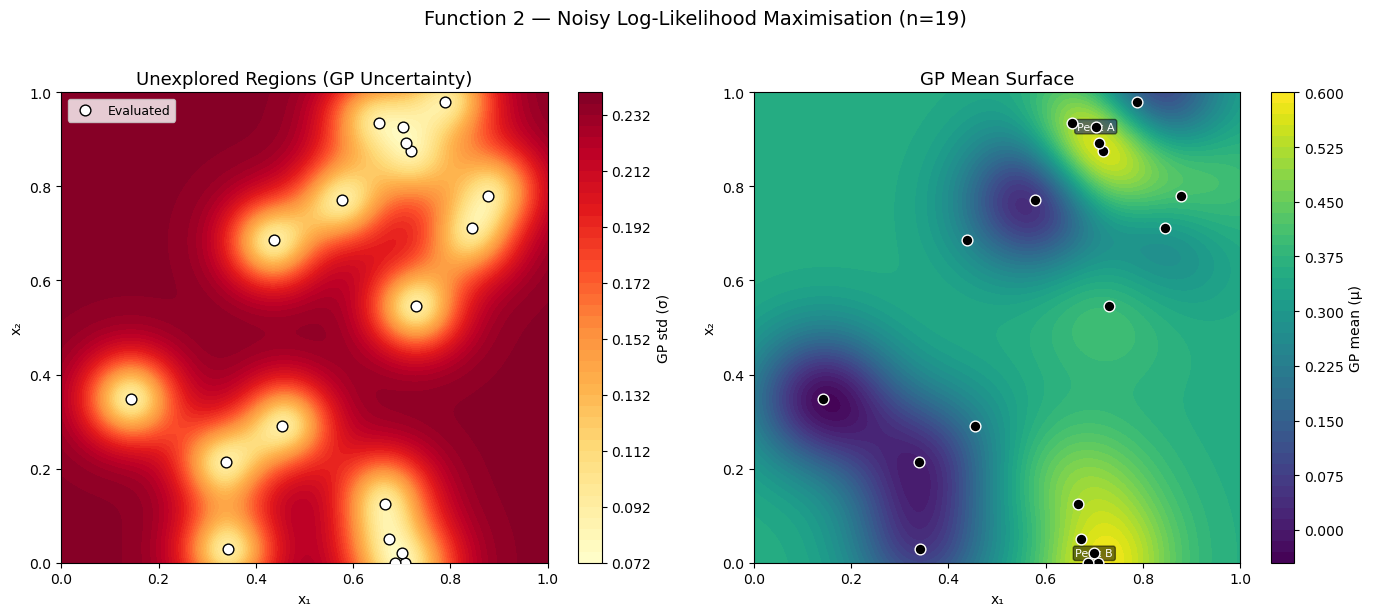

In [22]:
# --- Prediction grid for plotting (independent of acquisition candidates) ---
n_grid = 200
x1g, x2g = np.meshgrid(np.linspace(0, 1, n_grid), np.linspace(0, 1, n_grid))
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

mu_grid, sigma_grid = gpr.predict(X_grid, return_std=True)
mu_plot = mu_grid.reshape(n_grid, n_grid)
sigma_plot = sigma_grid.reshape(n_grid, n_grid)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Uncertainty
im1 = axes[0].contourf(x1g, x2g, sigma_plot, levels=50, cmap='YlOrRd')
axes[0].scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=60, zorder=5, label='Evaluated')
plt.colorbar(im1, ax=axes[0], label='GP std (σ)')
axes[0].set_title('Unexplored Regions (GP Uncertainty)', fontsize=13)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].legend(loc='upper left', fontsize=9)

# Panel 2: Mean surface (sequential — higher = better, maximisation)
im2 = axes[1].contourf(x1g, x2g, mu_plot, levels=50, cmap='viridis')
axes[1].scatter(X[:, 0], X[:, 1], c='black', edgecolors='white', s=60, zorder=5, label='Evaluated')
plt.colorbar(im2, ax=axes[1], label='GP mean (μ)')
axes[1].annotate('Peak B', xy=(0.700, 0.020), fontsize=8, color='white',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))
axes[1].annotate('Peak A', xy=(0.703, 0.927), fontsize=8, color='white',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='navy', alpha=0.5))
axes[1].set_title('GP Mean Surface', fontsize=13)
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂')

plt.suptitle(f'Function 2 — Noisy Log-Likelihood Maximisation (n={len(y)})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('./Figures/Function2_exploration_signal.png', dpi=150, bbox_inches='tight')
plt.show()